In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
# v2 是 torchvision.transforms 的新版图像变换 API，不是 Python 或 PyTorch 的版本号。
# 后面可以用 v2.Compose、v2.ToImage、v2.ToDtype 来写新版预处理流程。
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [ ]:
# transform 是每次读取图片时要执行的预处理流程。
# v2.Compose 会按顺序执行里面的步骤：ToImage 先把 PIL 图片转成图像 Tensor，
# ToDtype(torch.float32, scale=True) 再把像素转为 float32，并通常从 0~255 缩放到 0~1。
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100.0%
100.0%
100.0%
100.0%


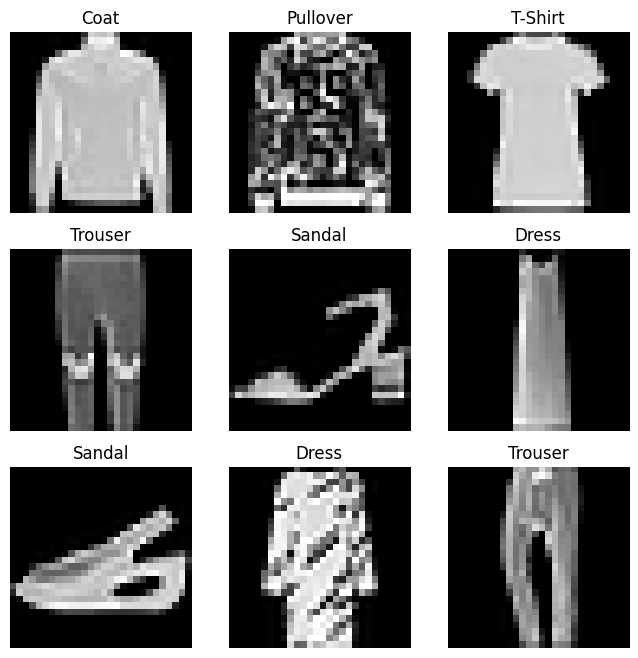

In [7]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    # len(training_data) 是训练集样本总数。
    # torch.randint(len(training_data), size=(1,)) 会在 [0, len(training_data)-1] 中随机生成 1 个整数。
    # size=(1,) 表示结果是一维 Tensor，形状是 [1]，比如 tensor([23841])。
    # 如果写 size=(1, 1)，结果是二维 Tensor，形状是 [1, 1]，比如 tensor([[23841]])。
    # 这里最后用 .item() 把只有一个元素的 Tensor 转成普通 Python 整数，方便作为数据集下标。

    # 如果写成其他的：
    # torch.randint(10, size=(3,))
    # 生成 3 个随机数：
    # tensor([2, 7, 4])
    # torch.randint(10, size=(2, 3))
    # 生成一个 2 行 3 列的随机整数矩阵：
    # tensor([[1, 8, 3],
    #         [6, 0, 9]])

    # 如果写成：
    # torch.randint(10, size=())
    # 生成一个“标量 tensor”：
    # tensor(7)
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    # training_data[sample_idx] 返回一组数据：(图片, 标签数字)。
    # FashionMNIST 中每张图片都提前配好了一个数字标签，比如 0 表示 T-Shirt，9 表示 Ankle Boot。
    # 经过上面的 transform 后，img 是 PyTorch Tensor，形状通常是 [1, 28, 28]。
    # 这里的 [1, 28, 28] 表示 [通道数, 高度, 宽度]，1 是因为 FashionMNIST 是灰度图。
    img, label = training_data[sample_idx]
    # 在 figure 这张大图里添加一个子图位置。
    # figure.add_subplot(rows, cols, i) 表示把大图分成 rows 行、cols 列，并选中第 i 个位置。
    # 这里 rows=3、cols=3，所以会画一个 3x3 的九宫格。
    figure.add_subplot(rows, cols, i)
    # label 是数字，labels_map[label] 把数字标签映射成人能看懂的类别名称。
    plt.title(labels_map[label])
    plt.axis("off")
    # plt.imshow(...) 才是真正接收图片数据并画图的函数，plt.show() 只是把前面画好的图显示出来。
    # 对灰度图，imshow 更习惯接收 [高度, 宽度]，比如 [28, 28]。
    # img.squeeze() 会去掉大小为 1 的维度，把 [1, 28, 28] 变成 [28, 28]。
    # 这里的 squeeze 不是压缩图片质量或文件大小，只是去掉多余的维度。
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [9]:
import os
import pandas as pd
from torchvision.io import decode_image

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label